Test cointegration between each of the following pairs:
1. corn & soy
2. corn & wheat
3. corn & cotton
4. soy & wheat
5. soy & cotton
6. wheat & cotton

## General

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

tickers = {'ZC=F': 'corn', 'ZS=F': 'soy', 'ZW=F': 'wheat', 'CT=F': 'cotton'}
prices = {}
for ticker, name in tickers.items():
    data = yf.download(ticker, start='2000-01-01', auto_adjust=True, timeout=10)
    prices[name] = data['Close'].squeeze()
    print(f"{name}: {data.index[0].date()} to {data.index[-1].date()}, {len(data)} rows")

df = pd.DataFrame(prices).dropna()
print(f"\nMerged shape: {df.shape}")
print(f"Date range:   {df.index[0].date()} to {df.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed


corn: 2000-07-17 to 2026-04-20, 6444 rows


[*********************100%***********************]  1 of 1 completed


soy: 2000-09-15 to 2026-04-20, 6436 rows


[*********************100%***********************]  1 of 1 completed


wheat: 2000-07-17 to 2026-04-20, 6456 rows


[*********************100%***********************]  1 of 1 completed

cotton: 2000-01-03 to 2026-04-20, 6594 rows

Merged shape: (6360, 4)
Date range:   2000-09-18 to 2026-04-20


In [17]:
def plot_prices(df, asset1, asset2):
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(df.index, df[asset1], color='steelblue', linewidth=0.8, label=asset1)
    ax1.set_ylabel(asset1, color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(df.index, df[asset2], color='seagreen', linewidth=0.8, label=asset2)
    ax2.set_ylabel(asset2, color='seagreen')
    ax2.tick_params(axis='y', labelcolor='seagreen')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f'{asset1} vs {asset2}')
    plt.tight_layout()
    plt.show()

In [13]:
def test_pair(df, asset1, asset2):
    """
    Engle-Granger cointegration test + OLS half-life estimate for a pair.
    
    Parameters
    ----------
    df : pd.DataFrame — must contain asset1 and asset2 columns
    asset1, asset2 : str — column names
    
    Prints p-value, half-life, and hedge ratio.
    """
    series1 = df[asset1]
    series2 = df[asset2]
    
    # Engle-Granger test
    score, pvalue, _ = coint(series1, series2)
    
    # OLS hedge ratio: series2 = alpha + gamma * series1 + epsilon
    X = add_constant(series1)
    ols_result = OLS(series2, X).fit()
    gamma = ols_result.params[asset1]
    alpha = ols_result.params['const']
    resid = ols_result.resid
    
    # Half-life via AR(1) on residual
    resid_lag  = resid.shift(1).dropna()
    resid_diff = resid.diff().dropna()
    phi = OLS(resid_diff, resid_lag).fit().params.iloc[0]
    half_life  = -np.log(2) / phi if phi < 0 else np.inf
    
    # Spread stats
    spread = series2 - alpha - gamma * series1
    
    print(f"Pair: {asset1.upper()} vs {asset2.upper()}")
    print(f"Engle-Granger p-value:  {pvalue:.4f}  "f"{'*** COINTEGRATED' if pvalue < 0.05 else '(not significant)'}")
    print(f"Hedge ratio (gamma):    {gamma:.4f}")
    print(f"Intercept (alpha):      {alpha:.4f}")
    print(f"Half-life:              {half_life:.1f} trading days")
    print(f"Spread mean:            {spread.mean():.4f}")
    print(f"Spread std:             {spread.std():.4f}")
    print(f"Spread min/max:         {spread.min():.2f} / {spread.max():.2f}")
    
    return {
        'pair': f"{asset1}_vs_{asset2}",
        'pvalue': pvalue,
        'gamma': gamma,
        'half_life': half_life,
        'cointegrated': pvalue < 0.05,
    }

Corn & soy

Pair: CORN vs SOY
Engle-Granger p-value:  0.0078  *** COINTEGRATED
Hedge ratio (gamma):    1.9026
Intercept (alpha):      224.8404
Half-life:              78.6 trading days
Spread mean:            -0.0000
Spread std:             126.2181
Spread min/max:         -334.93 / 411.16


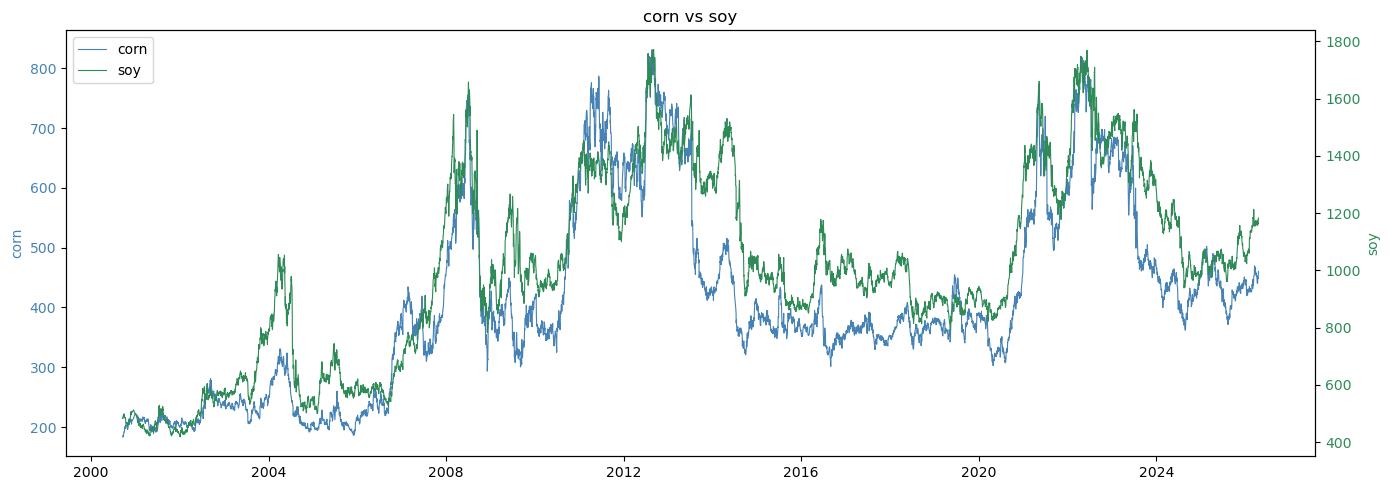

In [18]:
result_corn_soy = test_pair(df, 'corn', 'soy')
plot_prices(df,'corn','soy')

corn & wheat

Pair: CORN vs WHEAT
Engle-Granger p-value:  0.0075  *** COINTEGRATED
Hedge ratio (gamma):    0.9927
Intercept (alpha):      129.7684
Half-life:              77.9 trading days
Spread mean:            -0.0000
Spread std:             85.4735
Spread min/max:         -191.58 / 629.04


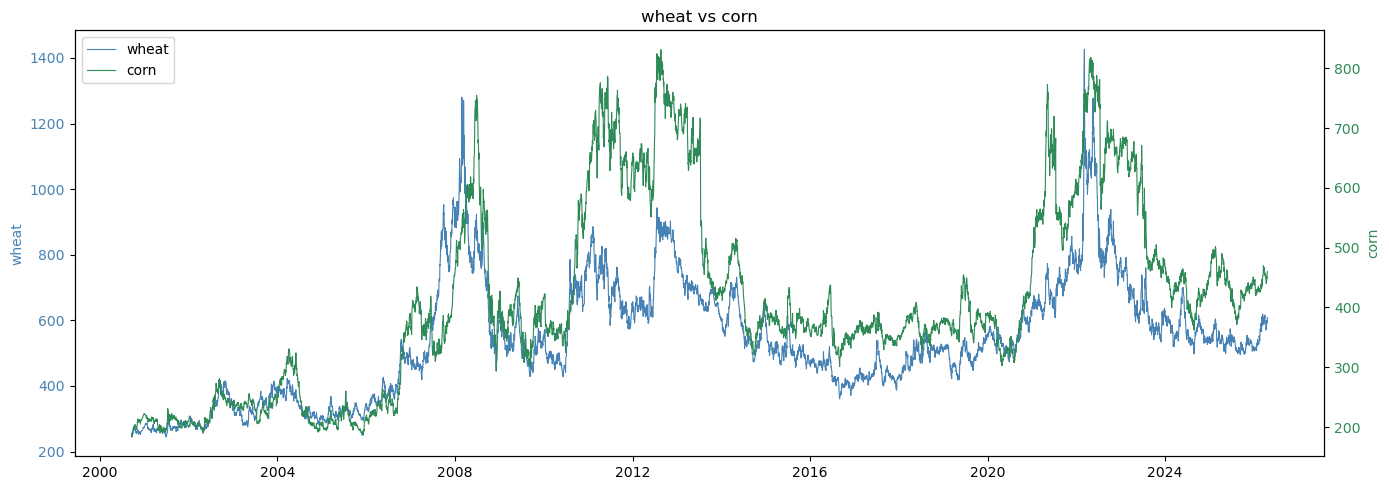

In [19]:
result_corn_wheat = test_pair(df, 'corn', 'wheat')
plot_prices(df,'wheat', 'corn')

corn & cotton

Pair: CORN vs COTTON
Engle-Granger p-value:  0.0052  *** COINTEGRATED
Hedge ratio (gamma):    0.1115
Intercept (alpha):      25.7223
Half-life:              137.1 trading days
Spread mean:            0.0000
Spread std:             17.0314
Spread min/max:         -46.52 / 109.54


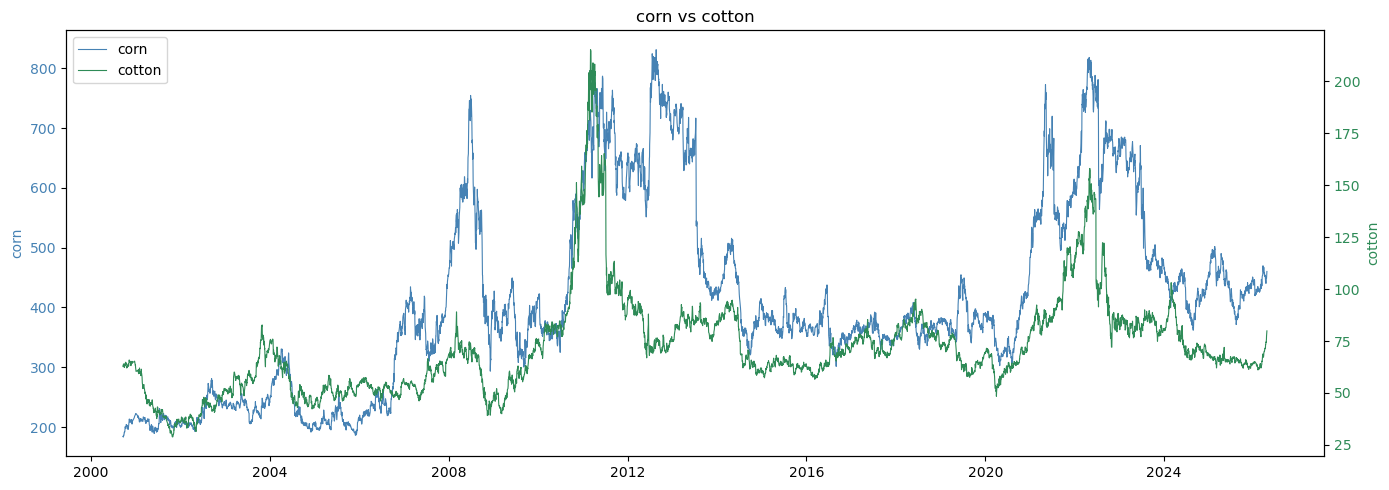

In [20]:
result_corn_cotton = test_pair(df, 'corn', 'cotton')
plot_prices(df,'corn','cotton')

soy & wheat

Pair: SOY vs WHEAT
Engle-Granger p-value:  0.0023  *** COINTEGRATED
Hedge ratio (gamma):    0.4740
Intercept (alpha):      60.9232
Half-life:              63.7 trading days
Spread mean:            0.0000
Spread std:             88.8064
Spread min/max:         -198.65 / 570.75


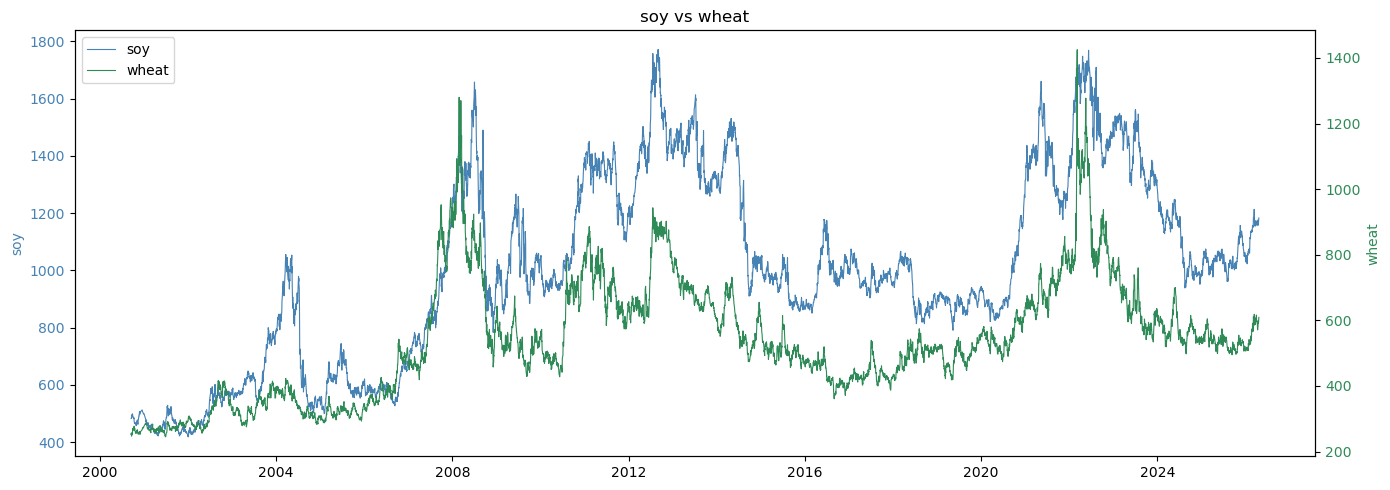

In [21]:
result_soy_wheat = test_pair(df, 'soy', 'wheat')
plot_prices(df,'soy','wheat')

soy & cotton

Pair: SOY vs COTTON
Engle-Granger p-value:  0.0208  *** COINTEGRATED
Hedge ratio (gamma):    0.0515
Intercept (alpha):      19.7361
Half-life:              151.5 trading days
Spread mean:            -0.0000
Spread std:             17.7771
Spread min/max:         -38.21 / 123.28


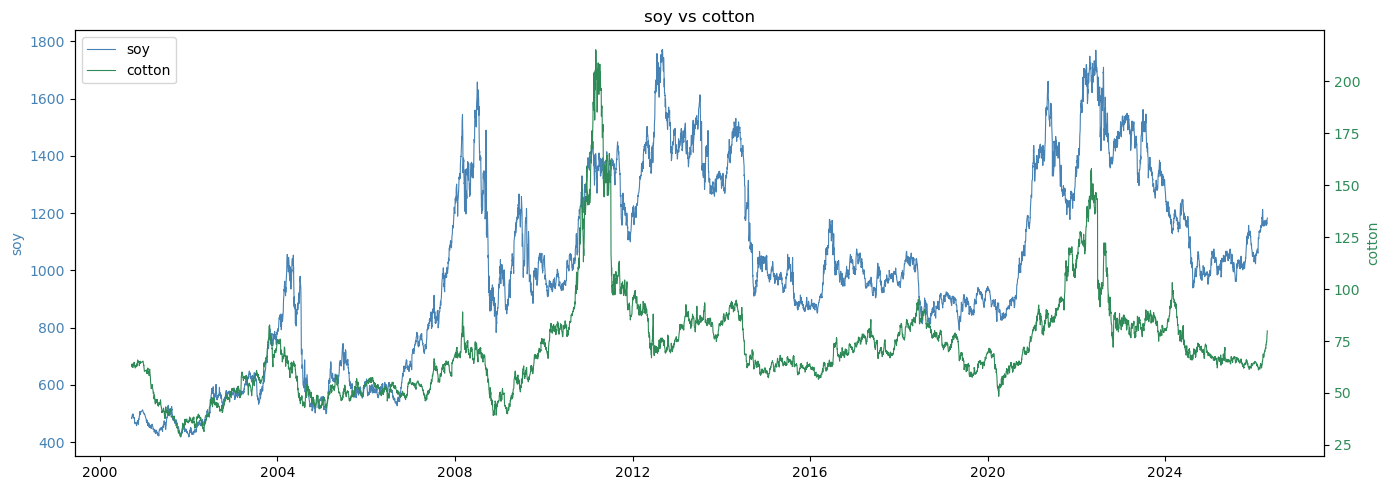

In [22]:
result_soy_cotton = test_pair(df, 'soy', 'cotton')
plot_prices(df,'soy','cotton')

wheat & cotton

Pair: WHEAT vs COTTON
Engle-Granger p-value:  0.0105  *** COINTEGRATED
Hedge ratio (gamma):    0.0876
Intercept (alpha):      24.5438
Half-life:              150.6 trading days
Spread mean:            0.0000
Spread std:             18.7530
Spread min/max:         -59.79 / 122.61


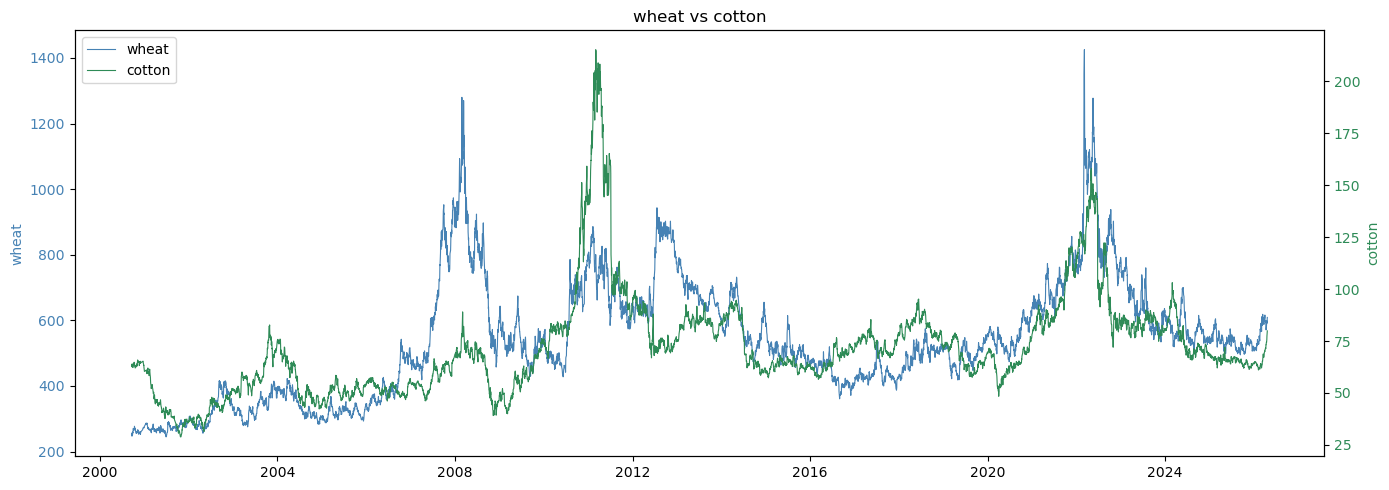

In [23]:
result_wheat_cotton = test_pair(df, 'wheat', 'cotton')
plot_prices(df,'wheat', 'cotton')

In [ ]:
results = [
    result_corn_soy,
    result_corn_wheat,
    result_corn_cotton,
    result_soy_wheat,
    result_soy_cotton,
    result_wheat_cotton,
]

summary = pd.DataFrame(results).sort_values('half_life')
summary['half_life'] = summary['half_life'].round(1)
summary['pvalue']    = summary['pvalue'].round(4)
summary['gamma']     = summary['gamma'].round(4)

print("\nAll pairs ranked by half-life (shorter = faster mean reversion = better):")
print("="*75)
print(f"{'Pair':<25} {'p-value':>10} {'Cointegrated':>14} {'Half-life':>12} {'Gamma':>8}")
print("-"*75)
for _, row in summary.iterrows():
    coint_str = "YES ***" if row['cointegrated'] else "no"
    hl = f"{row['half_life']:.1f} days" if row['half_life'] != np.inf else "inf"
    print(f"{row['pair']:<25} {row['pvalue']:>10.4f} {coint_str:>14} {hl:>12} {row['gamma']:>8.4f}")
print("="*75)
print("\nIdeal pair: p < 0.05 AND half-life < 60 days")


All pairs ranked by half-life (shorter = faster mean reversion = better):
Pair                         p-value   Cointegrated    Half-life    Gamma
---------------------------------------------------------------------------
soy_vs_wheat                  0.0023        YES ***    63.7 days   0.4740
corn_vs_wheat                 0.0075        YES ***    77.9 days   0.9927
corn_vs_soy                   0.0078        YES ***    78.6 days   1.9026
corn_vs_cotton                0.0052        YES ***   137.1 days   0.1115
wheat_vs_cotton               0.0105        YES ***   150.6 days   0.0876
soy_vs_cotton                 0.0208        YES ***   151.5 days   0.0515

Ideal pair: p < 0.05 AND half-life < 60 days
